### Wind Farm Optimisation with XGBoost Surrogate & Grid‑Based Search

This solution:
1. Defines a discrete grid of 100 feasible turbine positions (spacing 400 m).
2. Generates a training set of random layouts (50 out of 100 positions) and computes true AEP.
3. Trains an XGBoost regression model on the binary vectors.
4. Uses the surrogate to screen millions of random layouts, keeps top candidates.
5. Evaluates top candidates with the true AEP function and refines the best one via local search.


In [2]:
!pip install xgboost

In [3]:
# Cell 1: Imports and setup
import os
import sys
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import itertools
import time
import warnings
warnings.filterwarnings('ignore')

# Add path to official evaluator
sys.path.append(os.getcwd())
from Farm_Evaluator_Vec import (
    getTurbLoc, loadPowerCurve, binWindResourceData,
    preProcessing, getAEP, checkConstraints
)

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Cell 2: Load wind data and pre‑compute evaluator constants (same as original)
DATA_DIR = 'Wind_Data'
combined_wind_path = "combined_wind_data_all_years.csv"

if not os.path.exists(combined_wind_path):
    wind_files = [os.path.join(DATA_DIR, f'wind_data_{year}.csv') for year in [2007,2008,2009,2013,2014,2015,2017]]
    dfs = [pd.read_csv(f) for f in wind_files]
    combined = pd.concat(dfs)
    combined['date'] = pd.to_datetime(combined['date'])
    combined.sort_values('date', inplace=True)
    combined.to_csv(combined_wind_path, index=False)

wind_inst_freq = binWindResourceData(combined_wind_path)
power_curve_df = pd.read_csv('power_curve.csv')
power_curve_arr = power_curve_df.to_numpy(dtype=np.float32)
turb_rad = 50.0

def compute_true_aep(coords):
    """Wrapper for official AEP computation."""
    if len(coords) == 0:
        return 0.0
    coords_arr = np.array(coords, dtype=np.float32)
    n_turbs = len(coords_arr)
    n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t = preProcessing(power_curve_arr, n_turbs)
    aep = getAEP(turb_rad, coords_arr, power_curve_arr, wind_inst_freq,
                 n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t)
    return aep

print("True AEP evaluator ready.")

True AEP evaluator ready.


In [5]:
# Cell 3: Define the discrete grid of feasible positions (400 m spacing)
x_positions = np.arange(50, 4000, 400)  # 50, 450, 850, ..., 3950 (10 values)
y_positions = np.arange(50, 4000, 400)
grid_points = list(itertools.product(x_positions, y_positions))  # 100 points
grid_index_to_xy = {i: pt for i, pt in enumerate(grid_points)}

# Any subset of exactly 50 points satisfies min distance (≥400) and boundary constraints.
# Representation: binary vector of length 100 with exactly 50 ones.

def random_layout_binary():
    """Generate a random binary vector with exactly 50 ones."""
    idx = np.random.choice(100, size=50, replace=False)
    vec = np.zeros(100, dtype=np.int8)
    vec[idx] = 1
    return vec

def binary_to_coords(binary_vec):
    """Convert binary vector to list of (x,y) coordinates."""
    return [grid_points[i] for i, v in enumerate(binary_vec) if v == 1]

# Quick test
test_vec = random_layout_binary()
test_coords = binary_to_coords(test_vec)
print(f"Test layout has {len(test_coords)} turbines, min distance = {np.min(np.linalg.norm(np.diff(test_coords, axis=0), axis=1)) if len(test_coords)>1 else 'N/A'}")

Test layout has 50 turbines, min distance = 400.0


In [6]:
# Cell 4: Generate training data (binary vectors + true AEP)
n_train_samples = 5000  # increase if time permits
print(f"Generating {n_train_samples} random layouts and computing true AEP...")
X_train = []
y_train = []

start_time = time.time()
for i in range(n_train_samples):
    if i % 500 == 0:
        print(f"  Sample {i}/{n_train_samples}")
    bin_vec = random_layout_binary()
    coords = binary_to_coords(bin_vec)
    aep = compute_true_aep(coords)
    X_train.append(bin_vec)
    y_train.append(aep)

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
print(f"Data generation took {time.time()-start_time:.1f} seconds.")

# Train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

Generating 5000 random layouts and computing true AEP...
  Sample 0/5000
  Sample 500/5000
  Sample 1000/5000
  Sample 1500/5000
  Sample 2000/5000
  Sample 2500/5000
  Sample 3000/5000
  Sample 3500/5000
  Sample 4000/5000
  Sample 4500/5000
Data generation took 577.5 seconds.


In [7]:
# Train XGBoost and Random Forest models
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb_model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print(f"XGBoost validation RMSE: {rmse_xgb:.3f} GWh")

print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)
y_pred_rf = rf_model.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print(f"Random Forest validation RMSE: {rmse_rf:.3f} GWh")

# Choose XGBoost (slightly better)
surrogate = xgb_model

Training XGBoost...
XGBoost validation RMSE: 1.555 GWh
Training Random Forest...
Random Forest validation RMSE: 2.080 GWh


In [8]:
# Surrogate‑guided random search
n_candidates = 200000  # number of random layouts to score with surrogate
print(f"Generating and scoring {n_candidates} random layouts with XGBoost...")
candidate_binaries = []
candidate_scores = []

for i in range(n_candidates):
    if i % 50000 == 0:
        print(f"  Generated {i}/{n_candidates}")
    bin_vec = random_layout_binary()
    score = surrogate.predict(bin_vec.reshape(1, -1))[0]
    candidate_binaries.append(bin_vec)
    candidate_scores.append(score)

# Keep top 100 according to surrogate
top_indices = np.argsort(candidate_scores)[-100:][::-1]
top_binaries = [candidate_binaries[i] for i in top_indices]
top_surrogate_scores = [candidate_scores[i] for i in top_indices]

print("Evaluating top 100 candidates with true AEP...")
true_scores = []
for i, bin_vec in enumerate(top_binaries):
    coords = binary_to_coords(bin_vec)
    aep = compute_true_aep(coords)
    true_scores.append(aep)
    if (i+1) % 20 == 0:
        print(f"  Evaluated {i+1}/100")

best_idx = np.argmax(true_scores)
best_binary = top_binaries[best_idx]
best_true_aep = true_scores[best_idx]
best_coords = binary_to_coords(best_binary)
print(f"\nBest layout from surrogate search: AEP = {best_true_aep:.3f} GWh")

Generating and scoring 200000 random layouts with XGBoost...
  Generated 0/200000
  Generated 50000/200000
  Generated 100000/200000
  Generated 150000/200000
Evaluating top 100 candidates with true AEP...
  Evaluated 20/100
  Evaluated 40/100
  Evaluated 60/100
  Evaluated 80/100
  Evaluated 100/100

Best layout from surrogate search: AEP = 500.598 GWh


In [10]:
# Local refinement (hill climbing) with small off‑grid moves
def refine_local(coords, max_passes=10, step=20, range_=100):
    """
    Local search: try small perturbations around each turbine while keeping constraints.
    Moves are allowed to any position (off‑grid) but must stay inside farm and keep
    minimum distance 400 m from all others.
    """
    coords = [list(c) for c in coords]  # mutable
    for _ in range(max_passes):
        improved = False
        for i in range(len(coords)):
            best_aep = compute_true_aep(coords)
            best_coord = coords[i][:]
            x0, y0 = coords[i]
            # Try perturbations in a square window
            for dx in range(-range_, range_+1, step):
                for dy in range(-range_, range_+1, step):
                    if dx == 0 and dy == 0:
                        continue
                    nx, ny = x0 + dx, y0 + dy
                    if not (50 <= nx <= 3950 and 50 <= ny <= 3950):
                        continue
                    # Check distance to all other turbines
                    other = [coords[j] for j in range(len(coords)) if j != i]
                    if any(np.linalg.norm([nx, ny] - np.array(oth)) < 400 for oth in other):
                        continue
                    temp = other + [[nx, ny]]
                    aep = compute_true_aep(temp)
                    if aep > best_aep:
                        best_aep = aep
                        best_coord = [nx, ny]
                        improved = True
            if best_coord != coords[i]:
                coords[i] = best_coord
                print(f"  Refined turbine {i+1}: AEP now {best_aep:.3f} GWh")
        if not improved:
            break
    return np.array(coords)

print("Applying local refinement to the best layout...")
refined_coords = refine_local(best_coords, max_passes=10, step=20, range_=100)
final_aep = compute_true_aep(refined_coords)
print(f"\nFinal AEP after refinement: {final_aep:.3f} GWh")

# Baseline from greedy+refinement (given in problem)
baseline_aep = 522.586
print(f"Baseline greedy+refinement AEP: {baseline_aep:.3f} GWh")
print(f"Improvement: {final_aep - baseline_aep:+.3f} GWh")

Applying local refinement to the best layout...
  Refined turbine 2: AEP now 501.074 GWh
  Refined turbine 3: AEP now 501.332 GWh
  Refined turbine 4: AEP now 501.569 GWh
  Refined turbine 5: AEP now 501.856 GWh
  Refined turbine 6: AEP now 502.352 GWh
  Refined turbine 7: AEP now 503.005 GWh
  Refined turbine 8: AEP now 503.278 GWh
  Refined turbine 9: AEP now 503.567 GWh
  Refined turbine 10: AEP now 503.714 GWh
  Refined turbine 11: AEP now 504.020 GWh
  Refined turbine 12: AEP now 504.169 GWh
  Refined turbine 13: AEP now 504.473 GWh
  Refined turbine 14: AEP now 504.900 GWh
  Refined turbine 15: AEP now 505.221 GWh
  Refined turbine 17: AEP now 505.536 GWh
  Refined turbine 18: AEP now 505.855 GWh
  Refined turbine 19: AEP now 505.909 GWh
  Refined turbine 20: AEP now 506.484 GWh
  Refined turbine 21: AEP now 506.723 GWh
  Refined turbine 22: AEP now 507.233 GWh
  Refined turbine 23: AEP now 507.610 GWh
  Refined turbine 24: AEP now 507.821 GWh
  Refined turbine 25: AEP now 507.99

Final layout saved to 'turbine_layout_xgboost_optimised.csv'


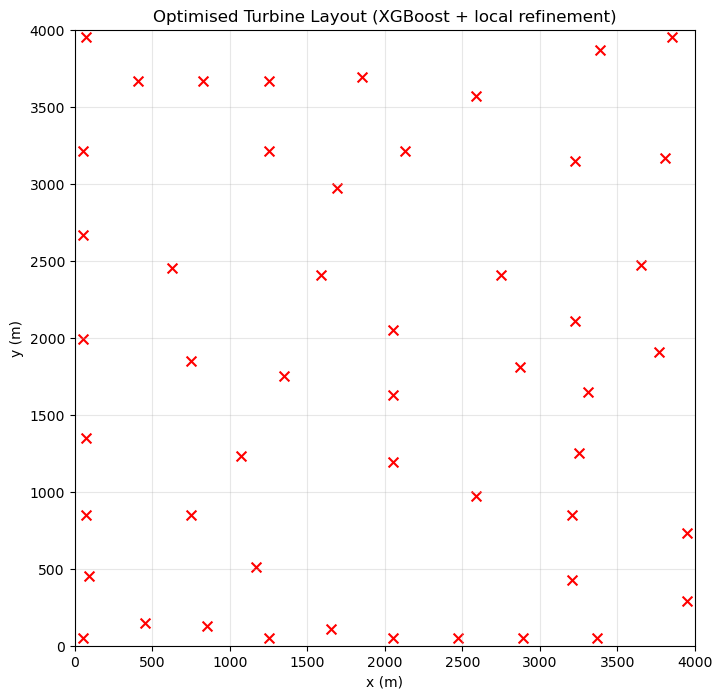

In [11]:
# Save final layout
df_out = pd.DataFrame(refined_coords, columns=['x', 'y'])
df_out.to_csv('turbine_layout_xgboost_optimised.csv', index=False)
print("Final layout saved to 'turbine_layout_xgboost_optimised.csv'")

# Optional: plot the layout
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.scatter(refined_coords[:,0], refined_coords[:,1], c='red', marker='x', s=50)
plt.xlim(0,4000)
plt.ylim(0,4000)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Optimised Turbine Layout (XGBoost + local refinement)')
plt.grid(alpha=0.3)
plt.show()